In [2]:
# we will use min max normalization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:
df = pd.read_csv('wine_data.csv', header = None, usecols = [0, 1, 2])
df.head()

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [7]:
df.columns = ['Class', 'Alcohol', 'Malic_acid']
df.head()

,Class,Alcohol,Malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [9]:
df[['Alcohol', 'Malic_acid']].describe()

,Alcohol,Malic_acid
count,178.000000,178.000000
mean,13.000618,2.336348
std,0.811827,1.117146
min,11.030000,0.740000
25%,12.362500,1.602500
50%,13.050000,1.865000
75%,13.677500,3.082500
max,14.830000,5.800000


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(df[['Alcohol', 'Malic_acid']], df['Class'], test_size = 0.2, random_state = 20)

In [11]:
# fitting min max scaler one
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scale = scaler.transform(X_train)
X_test_scale = scaler.transform(X_test)

In [14]:
X_train_scale = pd.DataFrame(X_train_scale, columns = ['Alcohol', 'Malic_acid'])
X_train_scale.head()

,Alcohol,Malic_acid
0,0.571053,0.205534
1,0.352632,0.084980
2,0.623684,0.626482
3,0.300000,0.140316
4,0.797368,0.175889


In [15]:
X_train_scale.describe()

,Alcohol,Malic_acid
count,142.000000,142.000000
mean,0.521201,0.309901
std,0.206822,0.218648
min,0.000000,0.000000
25%,0.352632,0.158103
50%,0.531579,0.218379
75%,0.686184,0.462945
max,1.000000,1.000000


In [16]:
# if we observe above after scaling min is 0 and max is 1 whcih is what we expected, now seeing those same things using graphs

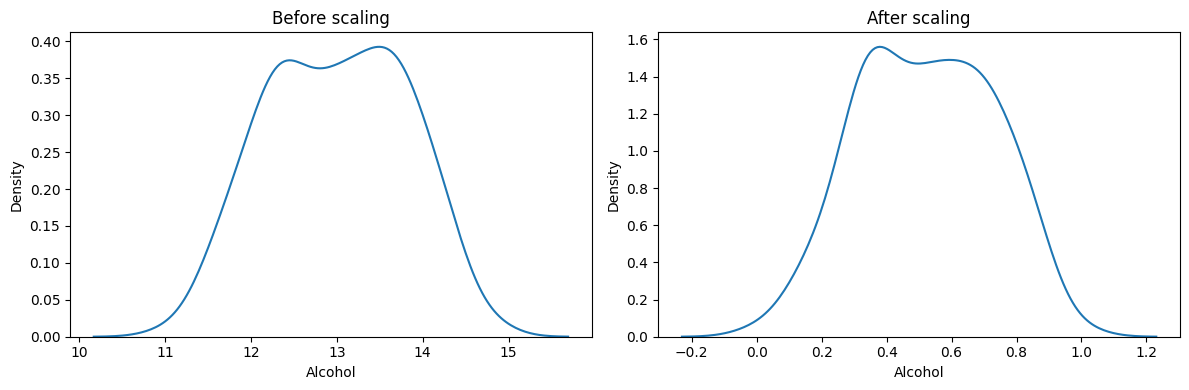

In [34]:
# Alcohol distribution
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 4))

sns.kdeplot(df['Alcohol'], ax = ax1)
ax1.set_title('Before scaling')

sns.kdeplot(X_train_scale['Alcohol'], ax = ax2)
ax2.set_title('After scaling')

plt.tight_layout()
plt.show()

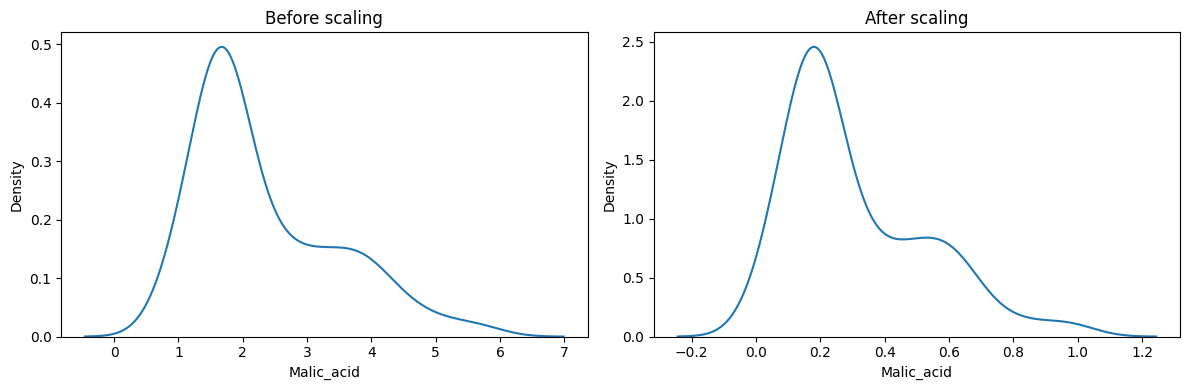

In [35]:
# Alcohol distribution
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 4))

sns.kdeplot(df['Malic_acid'], ax = ax1)
ax1.set_title('Before scaling')

sns.kdeplot(X_train_scale['Malic_acid'], ax = ax2)
ax2.set_title('After scaling')

plt.tight_layout()
plt.show()

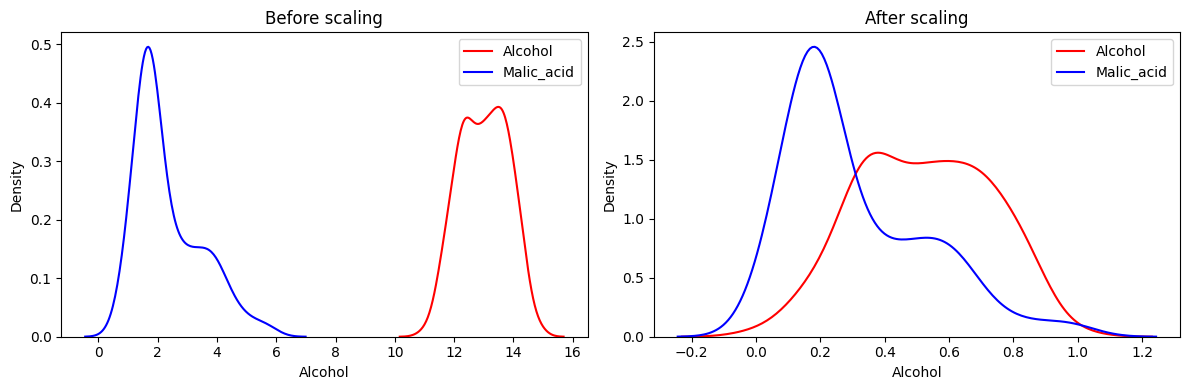

In [36]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 4))

sns.kdeplot(df['Alcohol'], ax = ax1, color = 'red', label = 'Alcohol')
sns.kdeplot(df['Malic_acid'], ax = ax1, color = 'blue', label = 'Malic_acid')
ax1.legend()
ax1.set_title('Before scaling')

sns.kdeplot(X_train_scale['Alcohol'], ax = ax2, color = 'red', label = 'Alcohol')
sns.kdeplot(X_train_scale['Malic_acid'], ax = ax2, color = 'blue', label = 'Malic_acid')
ax2.legend()
ax2.set_title('After scaling')

plt.tight_layout()
plt.show()

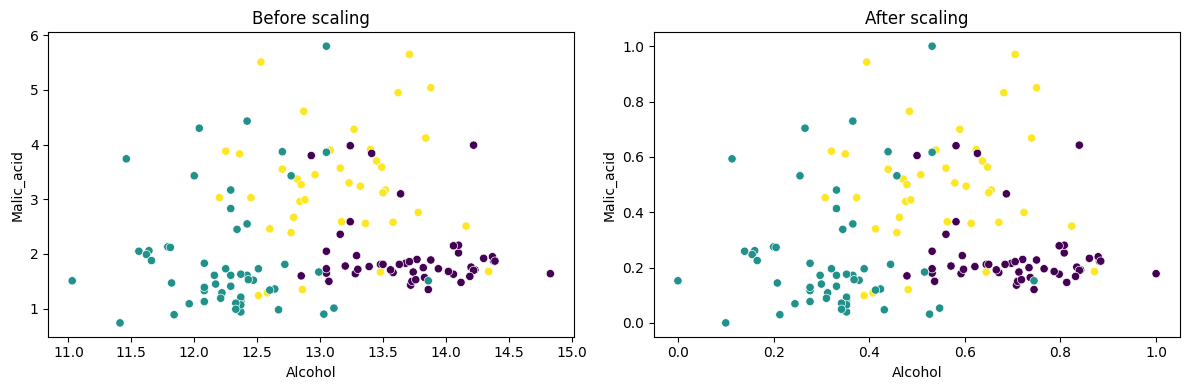

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 4))

sns.scatterplot(data = X_train, x = 'Alcohol', y = 'Malic_acid', c = Y_train, ax = ax1)
ax1.set_title('Before scaling')

sns.scatterplot(data = X_train_scale, x = 'Alcohol', y = 'Malic_acid', c = Y_train, ax = ax2)
ax2.set_title('After scaling')

plt.tight_layout()
plt.show()